In [8]:
!apt-get install -y openslide-tools
!pip install openslide-python --quiet


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openslide-tools is already the newest version (3.4.1+dfsg-5build1).
0 upgraded, 0 newly installed, 0 to remove and 165 not upgraded.


In [9]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

import openslide  # ← aquí

BASE = "/kaggle/input/mayo-clinic-strip-ai"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 10
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)


In [10]:
train_df = pd.read_csv(os.path.join(BASE, "train.csv"))

train_df = train_df.sample(700, random_state=SEED).reset_index(drop=True)

unique_labels = sorted(train_df["label"].unique())
label2id = {lbl: i for i, lbl in enumerate(unique_labels)}
id2label = {i: lbl for lbl, i in label2id.items()}
train_df["label_id"] = train_df["label"].map(label2id)

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label_id"],
    random_state=SEED
)

import torch

counts = train_df["label_id"].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(counts, dtype=torch.float32)
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)


In [11]:
import openslide
from pathlib import Path
from PIL import Image
import numpy as np
import random

IMG_DIR = Path(BASE) / "train"

class MayoSlideDataset(Dataset):
    def __init__(
        self,
        df,
        img_dir,
        transform=None,
        crop_size=512,
        random_crop=False,
        max_tries=3,
        blank_threshold=240,   # 0-255: más alto = más permisivo
    ):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.crop_size = crop_size
        self.random_crop = random_crop
        self.max_tries = max_tries
        self.blank_threshold = blank_threshold

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_id = row["image_id"]
        label_id = int(row["label_id"])

        slide_path = self.img_dir / f"{image_id}.tif"
        if not slide_path.exists():
            raise FileNotFoundError(slide_path)

        slide = openslide.OpenSlide(str(slide_path))

        # nivel más bajo
        level = slide.level_count - 1
        w, h = slide.level_dimensions[level]

        cw = min(self.crop_size, w)
        ch = min(self.crop_size, h)

        img = None

        for _ in range(self.max_tries):
            # elegir posición
            if self.random_crop and w > cw and h > ch:
                x = random.randint(0, w - cw)
                y = random.randint(0, h - ch)
            else:
                # centro mejor que esquina
                x = max(0, (w - cw) // 2)
                y = max(0, (h - ch) // 2)

            candidate = slide.read_region((x, y), level, (cw, ch)).convert("RGB")

            # checar si está muy blanco
            arr = np.array(candidate)
            if arr.mean() < self.blank_threshold:
                img = candidate
                break
            # si estaba blanco, vuelve a intentar con otro random (si está permitido) y sigue

        # si no encontró nada no-blanco después de max_tries, nos quedamos con el último candidate
        if img is None:
            img = candidate

        slide.close()

        if self.transform:
            img = self.transform(img)

        return img, label_id


In [12]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_ds = MayoSlideDataset(
    train_df,
    IMG_DIR,
    transform=train_tfms,
    crop_size=512,      
    random_crop=True    
)

val_ds = MayoSlideDataset(
    val_df,
    IMG_DIR,
    transform=val_tfms,
    crop_size=512,
    random_crop=False   
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)


In [13]:
NUM_CLASSES = len(label2id)

def get_model(num_classes):
    model = timm.create_model("efficientnet_b0", pretrained=True)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

model = get_model(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, acc, f1

def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)

            preds = outputs.argmax(1).detach().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, acc, f1

In [14]:
import matplotlib.pyplot as plt

history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

for epoch in range(EPOCHS):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader)
    val_loss, val_acc, val_f1 = eval_one_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["train_f1"].append(tr_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train: loss={tr_loss:.4f} acc={tr_acc:.4f} f1={tr_f1:.4f}")
    print(f"  Val:   loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}")


Epoch 1/10
  Train: loss=0.6261 acc=0.6357 f1=0.4623
  Val:   loss=0.6145 acc=0.7214 f1=0.5176
Epoch 2/10
  Train: loss=0.6042 acc=0.7286 f1=0.4340
  Val:   loss=0.5967 acc=0.7429 f1=0.5617
Epoch 3/10
  Train: loss=0.6092 acc=0.7143 f1=0.4342
  Val:   loss=0.6104 acc=0.7000 f1=0.4118
Epoch 4/10
  Train: loss=0.6039 acc=0.7232 f1=0.4319
  Val:   loss=0.6485 acc=0.6929 f1=0.4503
Epoch 5/10
  Train: loss=0.6097 acc=0.7286 f1=0.4215
  Val:   loss=0.5840 acc=0.7286 f1=0.4458
Epoch 6/10
  Train: loss=0.5991 acc=0.7161 f1=0.4292
  Val:   loss=0.5859 acc=0.7214 f1=0.4191
Epoch 7/10
  Train: loss=0.6028 acc=0.7232 f1=0.4259
  Val:   loss=0.5807 acc=0.7214 f1=0.4191
Epoch 8/10
  Train: loss=0.5888 acc=0.7286 f1=0.4340
  Val:   loss=0.5749 acc=0.7286 f1=0.4215
Epoch 9/10
  Train: loss=0.5892 acc=0.7196 f1=0.4364
  Val:   loss=0.5774 acc=0.7214 f1=0.4191
Epoch 10/10
  Train: loss=0.5949 acc=0.7268 f1=0.4209
  Val:   loss=0.5814 acc=0.7214 f1=0.4191


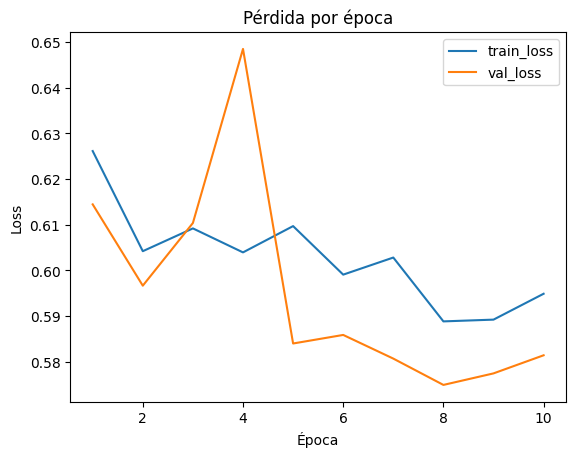

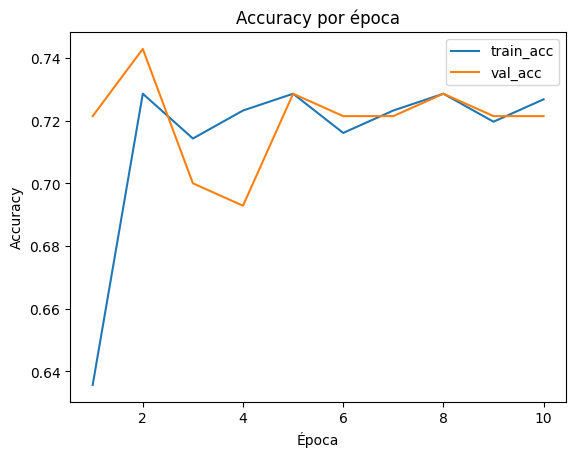

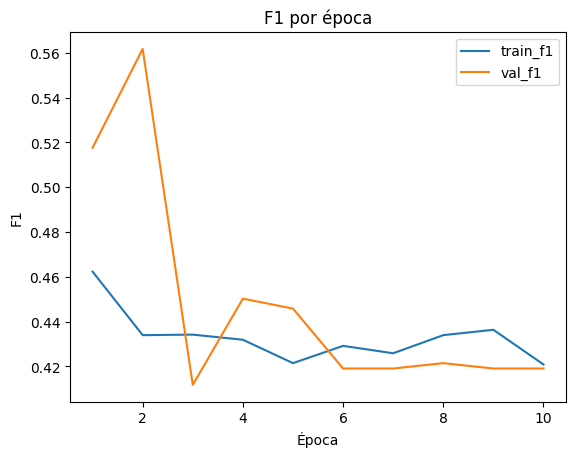

In [15]:
epochs_range = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs_range, history["train_loss"], label="train_loss")
plt.plot(epochs_range, history["val_loss"], label="val_loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Pérdida por época")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, history["train_acc"], label="train_acc")
plt.plot(epochs_range, history["val_acc"], label="val_acc")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy por época")
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs_range, history["train_f1"], label="train_f1")
plt.plot(epochs_range, history["val_f1"], label="val_f1")
plt.xlabel("Época")
plt.ylabel("F1")
plt.title("F1 por época")
plt.legend()
plt.show()


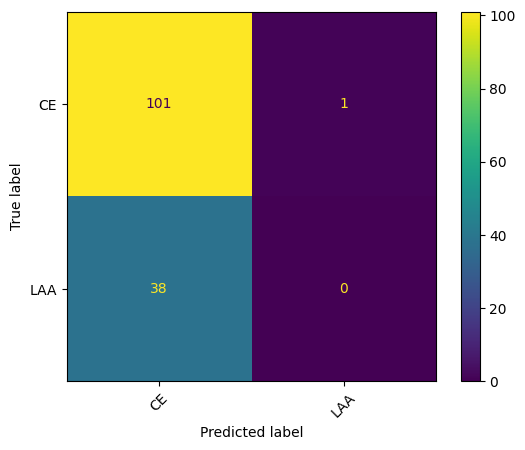

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=[id2label[i] for i in range(len(id2label))])
disp.plot(xticks_rotation=45)
plt.show()
